In [1]:
import os
import re
from dotenv import load_dotenv
import pandas as pd
from google import genai
from google.genai import types
from pydantic import BaseModel, Field 
from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pickle
import concurrent.futures
import json
from queue import Queue
from openai import OpenAI
from dotenv import load_dotenv
import random

c:\Users\princ\OneDrive\Desktop\Coding\Python\machine learning\genAI\Private Triage on device\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:


def create_high_recall_snapshot(subject: str, body: str) -> str:
    """
    Slices a long email into a dense layout optimized to preserve urgency cues
    while respecting strict local VRAM and token limits.
    """
    
    clean_body = " ".join(body.split())
    clean_body.replace(">" , "\n")
    
    if len(clean_body) <= 1000:
        return f"Subj: {subject}\nBody: {clean_body}"
        
    # 1. Grab the Head (Highly likely to contain the core intent)
    head = clean_body[:700]
    
    # 2. Grab the Tail (Highly likely to contain deadlines/actions)
    tail = clean_body[-300:]
    
    # 3. Now we don't know what the middle of the message is like so lets use dynamic approach (selecting the portion with urgent looking words and intent)
    urgency_keywords = r"(?i)(asap|urgent|broken|fail|blocker|deadline|critical|override|postpone|cancel)"
    middle_context = ""
    
    # Scan the hidden middle portion of the email
    middle_text = clean_body[700:-300]
    matches = list(re.finditer(urgency_keywords, middle_text))
    
    if matches:
        # Extract a 100-character window around the first critical match found
        first_match = matches[0]
        start = max(0, first_match.start() - 40)
        end = min(len(middle_text), first_match.end() + 60)
        middle_context = f"\n[MID-SIGNAL]: ... {middle_text[start:end]} ..."

    # 4. Construct the dense snapshot
    dense_input = (
        f"Subj: {subject}\n"
        f"Body-Head: {head} ...{middle_context}\n"
        f"Body-Tail: ... {tail}"
    )
    return dense_input

In [3]:
# data = load_dataset('Yale-LILY/aeslc')
df = pd.read_pickle('triage_dataset.pkl')

In [4]:
# train = data['train']
df.describe()
# test = data['test']
# validation = data['validation']

,message,intent_output,category
count,14434,14434,14434
unique,13551,13664,6
top,Subj: EFCU Gets You Connected\nBody: Get Conne...,Your mailbox is approaching its size limit of ...,Work
freq,15,21,11593


In [ ]:
# print(train[0])
df = df[:14200]


In [ ]:
l = []
for i in train:
    l.append(len(i['email_body']))
count = [1 for i in l if i>200]
print(l[19])

In [ ]:
print(train[100]) # As we can see that we cant judge a urgency of an email by its size
# So lets take the minimin body size to be 100 and below that will take the 

In [ ]:
plt.plot(l)
plt.title("Email_Body length distribution.")
plt.show()

In [3]:
BASEMODEL= "google/gemma-4-e4b"
MIN_CHAR=100
MAX_CHAR=1500


In [6]:
load_dotenv(override=True)
API_KEY = 'ollama3'
print(f"Your api key is : {API_KEY[:7]}")
BASE_URL = "http://localhost:11434/v1"  
MODEL_NAME = "llama3:latest"

client = OpenAI(api_key = API_KEY, base_url = BASE_URL)

categories = ["Urgent", "Scheduling", "Info", "Social", "Others"]


sys_prom = f"""You are a data labeling engine for notification triaging.
Your task is to analyse raw messages (which can be unformed chat messages or unstructured emails) and you task is to generate the output:
1. intent_output: It MUST be a informative one line summary of the message.
2. Category: Must be exactly one word from this list: {categories}.

---
Example Input:
Subj: Your approval is requested
Body: I don't know Mog Hue. Please return this request to the person who originated it so that the Manager section can be completed. By including the manager's name, that will help me to identify who this person is, what job they perform and whether or not the request makes sense. I have over 400 people in my group, so without more detail on these requests it is not worth taking my time to approve these. --Sally


Example Output:
intent_output: Sally is rejecting an unidentifiable approval request and directing it back to the originator for missing manager details.
Category: Urgent
---

You must respond only in the following formate. Do not write Intros, Outros or explainations:
intent_output: <informative-one-line-summary>
Category: <one-word-category>"""




Your api key is : ollama3


In [5]:
def labeling(raw_message):
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role" : "system", "content": sys_prom},
                {"role" : "user" , "content": f"Input_Message: \n{raw_message}"}
            ],
            temperature= 0.1,
            max_tokens= 150
            
        )
        output = response.choices[0].message.content.strip()
        intent_match = re.search(r"intent_output:\s*(.*)", output, re.IGNORECASE)
        category_match = re.search(r"Category:\s*(.*)", output, re.IGNORECASE)
        
        if intent_match:
            intents = intent_match.group(1).strip()
            
                
        if category_match:
            
            category = category_match.group(1).strip()
            for cat in categories:
                if cat.lower() in category.lower():
                    category = cat
                    break
        
        return {
                "message": raw_message,
                "intent_output": intents,
                "category": category,
            }
    except Exception as e:
        print(f"Error processing row: {e}")
    return None
        

In [ ]:
import re
from typing import Optional, Dict, Any
from transformers import AutoTokenizer

class TriageItem:
    # Use Gemma 4 / Llama 3.2 tokenizers cleanly
    tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-e4b", trust_remote_code=True)
    
    # Structural triggers for the local model's rationale chain
    THOUGHT_OPEN = "<|channel>thought\n"
    THOUGHT_CLOSE = "\n<channel|>"
    
    def __init__(self, raw_data: Dict[str, Any], max_tokens: int = 512):
        self.sender: str = raw_data.get("sender", "Unknown")
        self.subject: str = raw_data.get("subject", "No Subject")
        self.raw_body: str = raw_data.get("body", "")
        self.intent: str = raw_data.get("intent", "Info")
        self.rationale: str = raw_data.get("rationale", "")
        
        self.max_tokens = max_tokens
        self.prompt: Optional[str] = None
        self.include: bool = False
        
        self.process()

    def clean_whitespace(self, text: str) -> str:
        """Removes layout noise without destroying critical words/codes."""
        if not text:
            return ""
        # Collapse multiple spaces/newlines but keep structural integrity
        text = re.sub(re.compile(r'\s+'), ' ', text)
        return text.strip()

    def process(self):
        """Processes raw text and builds a balanced token-budget constraint prompt."""
        cleaned_body = self.clean_whitespace(self.raw_body)
        
        # Build standard system/user entry structure
        user_input = f"From: {self.sender} | Subj: {self.subject}\nBody: {cleaned_body}"
        
        # Tokenize early to protect character boundaries
        input_tokens = self.tokenizer.encode(user_input, add_special_tokens=False)
        
        # Guardrail: Enforce physical token ceilings for fast local GPU pre-fill
        if len(input_tokens) > self.max_tokens:
            input_tokens = input_tokens[:self.max_tokens]
            user_input = self.tokenizer.decode(input_tokens, skip_special_tokens=True)
            
        # Structure the golden target response (What Gemma 4 must learn to output)
        target_output = (
            f"{self.THOUGHT_OPEN}{self.rationale}{self.THOUGHT_CLOSE}"
            f"INTENT: {self.intent}"
        )
        
        # Assemble the fine-tuning training pair
        self.prompt = f"Instruction: Triage the following notification snapshot.\n\nInput:\n{user_input}\n\nOutput:\n{target_output}"
        self.include = True

    def test_prompt(self) -> str:
        """Returns the prompt sliced exactly where the local agent must begin generation."""
        return self.prompt.split("Output:\n")[0] + "Output:\n"

    def __repr__(self) -> str:
        return f"<TriageItem From={self.sender} Intent={self.intent}>"

In [ ]:
# train_new = [create_high_recall_snapshot(i['subject_line'], i["email_body"]) for i in train]
train_new = [
    f"{df.loc[i, 'message']}\n[[[[[INTENT]]]]]:{df.loc[i, 'intent_output']}"
    for i in df.index
]


In [ ]:
print(train_new[1000].split('[[[[[INTENT]]]]]:'))

In [30]:
CHUNK_SIZE = 500
OUTPUT_FILE = 'Triage_dataset_Next_3.pkl'
def process_batch(batch, executor):
    futures = {executor.submit(labeling, msg): msg for msg in batch}
    results = []
    for future in concurrent.futures.as_completed(futures):
        try:
            res = future.result()
            if res:
                results.append(res)
        except Exception as e:
            print(f"Error: {e}")
    return results

def stream_process(messages):
    generated = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        for i in range(0, len(messages), CHUNK_SIZE):
            batch = messages[i:i+CHUNK_SIZE]
            print(f"Processing batch {i//CHUNK_SIZE+1} ({len(batch)} items)...")
            batch_results = process_batch(batch, executor)
            generated.extend(batch_results)

            # Save progress incrementally
            df = pd.DataFrame(generated)
            with open(OUTPUT_FILE, "wb") as f:
                pickle.dump(df, f, protocol=pickle.HIGHEST_PROTOCOL)

            print(f"Saved {len(generated)} items so far...")

    return generated



In [ ]:
# import re
# import polars as pl
# from openai import OpenAI

# # 1. ROUTE CLIENT TO YOUR LOCAL HARDWARE ENGINES
# client = OpenAI(
#     base_url="http://localhost:11434/v1",  # Redirects SDK traffic to your own PC
#     api_key="ollama",                      # Required by the SDK but ignored by Ollama
# )

# # Set the exact tag string match of your pulled Ollama model
# MODEL_NAME = "llama3.1:8b"
# output_file = "gemma_triage_dataset.parquet"
# CATEGORIES = ["Work", "Casual", "Home", "Notice", "Social"]

# SYSTEM_PROMPT = """You are a data labeling engine for notification triaging. 
# Analyze raw messages and distill them into two strict outputs:
# Intent: <one-sentence-summary>
# Category: <one-word-category>"""

# # Array container representing your 14,436 source strings
# raw_unlabelled_data = [
#     "Body: I don't know Mog Hue. Please return this request...",
#     # ... all your lines stay right here
# ]

# # Structural resume handling to manage potential hardware drop-outs safely
# try:
#     df_existing = pl.read_parquet(output_file)
#     processed_messages = set(df_existing["raw_message"].to_list())
#     final_rows = df_existing.to_dicts()
#     print(f"Loaded existing data checkpoints. Resuming right from row {len(final_rows)}...")
# except FileNotFoundError:
#     processed_messages = set()
#     final_rows = []

# print(f"Processing local inference execution using standard OpenAI library mapping...")

# for idx, text in enumerate(raw_unlabelled_data):
#     if text in processed_messages:
#         continue

#     try:
#         # Standard OpenAI call format routes cleanly down to Ollama's local runner
#         response = client.chat.completions.create(
#             model=MODEL_NAME,
#             messages=[
#                 {"role": "system", "content": SYSTEM_PROMPT},
#                 {"role": "user", "content": f"Input Message:\n{text}"}
#             ],
#             temperature=0.1,
#             max_tokens=80
#         )
        
#         output_text = response.choices[0].message.content
        
#         # Pull values out with regex
#         intent_match = re.search(r"Intent:\s*(.*)", output_text, re.IGNORECASE)
#         category_match = re.search(r"Category:\s*(.*)", output_text, re.IGNORECASE)
        
#         intent = intent_match.group(1).strip() if intent_match else "N/A"
#         category = category_match.group(1).strip() if category_match else "N/A"
        
#         for cat in CATEGORIES:
#             if cat.lower() in category.lower():
#                 category = cat
#                 break
                
#         final_rows.append({
#             "raw_message": text,
#             "intent": intent,
#             "category": category
#         })
#         processed_messages.add(text)
        
#         # Save structural checkpoint logs every 50 records
#         if len(final_rows) % 50 == 0:
#             print(f"Progress Track: {len(final_rows)} / {len(raw_unlabelled_data)} successfully parsed.")
#             pl.DataFrame(final_rows).write_parquet(output_file)
            
#     except Exception as e:
#         print(f"Error processing index {idx}: {e}")
#         if final_rows:
#             pl.DataFrame(final_rows).write_parquet(output_file)
#         break

# # Final clean parquet file compilation block
# if final_rows:
#     pl.DataFrame(final_rows).write_parquet(output_file)
#     print(f"\n🎉 Done! Local compilation complete. Data matrix exported directly to {output_file}")

In [29]:
import pickle
import pandas as pd

# Define the exact same file name you used to save it
OUTPUT_FILE = "Triage_dataset_Next_2.pkl"

try:
    # Open and load the pickle file
    with open(OUTPUT_FILE, "rb") as f:
        df = pickle.load(f)
    
    # Print the total number of processed rows
    print(f"📊 Total Rows Processed successfully: {len(df)}")
    print("-" * 50)
    
    # Show the first 5 rows to check the content
    print("👀 First 5 rows of your dataset:")
    print(df.head())
    
    print("-" * 50)
    # Check the distribution of your categories to see how Llama classified them
    print("🗂️ Category Distribution Breakdown:")
    print(df['category'].value_counts())

except FileNotFoundError:
    print(f"❌ Error: Could not find '{OUTPUT_FILE}' in this directory. Make sure the path matches.")
except Exception as e:
    print(f"❌ An error occurred while loading the data: {e}")

📊 Total Rows Processed successfully: 13999
--------------------------------------------------
👀 First 5 rows of your dataset:
                                             message  \
0  Subj: A PICTURE STORY\nBody: ......most look l...   
1  Subj: (01-46) TERMINATION OF MEMBERS RETENTION...   
2  Subj: Setoff and ISDA Section 7(b) Transfer Pr...   
3  Subj: RE: Flood Workers\nBody: Guys John has c...   
4  Subj: Returned mail: Host unknown (Name server...   

                                       intent_output    category  
0  A picture story about flood damage is being sh...        Info  
1  The NYMEX division members' retention and reti...      Urgent  
2  Request for comments on ISDA Section 7(b) tran...        Info  
3  Lloyd is asked to provide estimates for weeken...  Scheduling  
4  The sender, Tana Jones, is planning a Saturday...      Social  
--------------------------------------------------
🗂️ Category Distribution Breakdown:
category
Info          7330
Scheduling    3695
U

In [ ]:
df = pd.read_pickle('Triage_dataset_Next.pkl')

In [ ]:
sample = []
for i in range(0, 400):
    if df['category'][i] == 'Social':
        sample.append((df['message'][i],
        df['intent_output'][i],
        df['category'][i]))
    if len(sample) == 50:
        break

In [ ]:
sample

In [ ]:
import random
def generate(sample):
    temp = random.choice(sample)
    sys_prom = f"""
    You are an advance data generating engine for private-triage. Your tast is to generate completely new high quality synthetic data with the help of the data provided.
    You MUST match the exact formatting of the reference example provided below. Output ONLY a valid Python string.
    EXAMPLE:
    -------------------------------------------------------------------------------------

    message: \n{temp[0]}
    Intent {temp[1]}
    category:  {temp[2]}

    -------------------------------------------------------------------------------------

    ### CRITICAL RULES:
    1. Create a completely brand-new situation, name, and topic. Do not repeat the reference example.
    2. Maintain the raw email realism (include Subj: and Body: tags, keep realistic human typos or shorthand if the reference has them).
    3. The category must be exactly 'Social'.
    4. Output NOTHING except the raw tuple string: ('Subj: ...\\nBody: ...', ':One line Intent...', 'Social')
    this is just the basic formate try to think above it and create a structured brand new social emaildata without any repetation.
    """
    return sys_prom
    


In [ ]:
print(generate(sample))

In [8]:
Extra_data = pd.read_csv('emails.csv')

In [9]:
print(len(Extra_data))

517401


In [10]:
messages = []
for i in Extra_data['message']:
    messages.append(i)

In [11]:
print(messages[1])

Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip without any formal business meetings.  I would even try and get some honest opinions on whether a trip is even desired or necessary.

As far as the business meetings, I think it would be more productive to try and stimulate discussions across the different groups about what is working and what is not.  Too often the

In [15]:


def parse_extra_data(data):  
    
    match = re.search(r"Subject:\s*(.*)", data)
    
    
    if not match or not match.group(1).strip():
        
        if "Mime-Version:" in data:
            return None
        subject_raw = ""
        
    else:
        subject_raw = match.group(1).strip()
    
    
    if subject_raw.startswith("Mime-Version:"):
        return None
        
    if subject_raw.startswith("Re:"):
        # Strip 'Re:' and any trailing spaces from the start
        subject = re.sub(r"^Re:\s*", "", subject_raw)
        if subject.startswith("Mime-Version:"):
            return None
    else:
        subject = subject_raw

    parts = data.split('\n\n')
    if len(parts) < 2:
        return None  # No body content present
        
    body = '\n'.join(parts[1:])
    cleaned = re.sub(r'[^A-Za-z0-9\s.,?!]', '', body)
    
   
    if cleaned.strip().startswith('Forwarded') or len(cleaned) <100:
        return 
    if not subject or not cleaned:
        return 


    return create_high_recall_snapshot(subject, cleaned)

In [13]:
messages[0]

"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>\nDate: Mon, 14 May 2001 16:39:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: tim.belden@enron.com\nSubject: \nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: Tim Belden <Tim Belden/Enron@EnronXGate>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pallen (Non-Privileged).pst\n\nHere is our forecast\n\n "

In [16]:
new_messages = []
for i in messages:
    k = parse_extra_data(i)
    if k:
        new_messages.append(k.split('\n\n')[0])
        



In [17]:
print(new_messages[0])
len(new_messages)

Subj: High Speed Internet Access
Body: 1. login pallen pw ke9davis I dont think these are required by the ISP 2. static IP address IP 64.216.90.105 Sub 255.255.255.248 gate 64.216.90.110 DNS 151.164.1.8 3. Company 0413 RC 105891


421246

In [18]:
import random
print(random.choice(new_messages))

Subj: Mildred & Chester
Body-Head: The cruelty of age Mildred and Chester knew each other from childhood but were in their nineties when they got married. They had to wait for Mildreds mother to pass away first. Back in those days there was no hanky panky before marriage so Chester and Mildred were both still virgins. Needless to say Chester was pretty excited on their wedding night. Having waited so patiently all these years. However, Mildred was very apprehensive as she had developed a heart condition and would have to tell Chester that they could not do it. Chester is now sitting on the bed wanting Mildred to hurry up. He detects a little reluctance on her part. Thinking that she is shy he sends her off to the bathroom to  ...
Body-Tail: ... strap and sees the second breast unroll downward before him. Poor Mildred is now beside herself. She is going to have to tell Chester about her heart. With a quivering voice and mustering up all her courage, she says Chester I have acute angina.

In [19]:
random.seed(42)
t = labeling(new_messages[0])
print(t['message'])
print(t['intent_output'])
print(t['category'])

Subj: High Speed Internet Access
Body: 1. login pallen pw ke9davis I dont think these are required by the ISP 2. static IP address IP 64.216.90.105 Sub 255.255.255.248 gate 64.216.90.110 DNS 151.164.1.8 3. Company 0413 RC 105891
Request for high-speed internet access configuration details.
Info


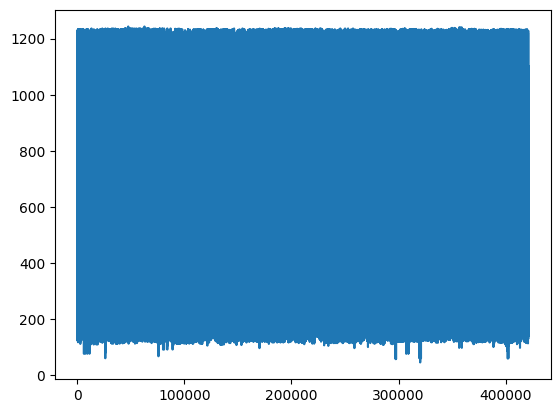

In [20]:
t = [len(i) for i in new_messages]
plt.plot(t)
plt.show()

In [21]:
seen = set()
unlabeled = []
for i in range(20*len(new_messages)):
    k = random.choice(new_messages)
    if k in seen:
        continue
    else:
        unlabeled.append(k)
        seen.add(k)

In [22]:
len(unlabeled)

205544

In [31]:
if __name__ == "__main__":
    # Replace with your dataset
    labeled = unlabeled[14000 : 20000]
    print(f"Streaming {len(labeled)} items in chunks of {CHUNK_SIZE}...")
    final_results = stream_process(labeled)
    print("✅ All done! Final dataset ready for Hugging Face deployment.")


Streaming 6000 items in chunks of 500...
Processing batch 1 (500 items)...
Saved 500 items so far...
Processing batch 2 (500 items)...
Saved 1000 items so far...
Processing batch 3 (500 items)...
Saved 1500 items so far...
Processing batch 4 (500 items)...
Saved 2000 items so far...
Processing batch 5 (500 items)...
Saved 2500 items so far...
Processing batch 6 (500 items)...
Saved 3000 items so far...
Processing batch 7 (500 items)...
Saved 3500 items so far...
Processing batch 8 (500 items)...
Saved 4000 items so far...
Processing batch 9 (500 items)...
Saved 4500 items so far...
Processing batch 10 (500 items)...
Saved 5000 items so far...
Processing batch 11 (500 items)...
Saved 5500 items so far...
Processing batch 12 (500 items)...
Error processing row: cannot access local variable 'intents' where it is not associated with a value
Saved 5999 items so far...
✅ All done! Final dataset ready for Hugging Face deployment.


In [7]:
df = pd.read_pickle('Triage_dataset_Next.pkl')

In [8]:
df.describe()

,message,intent_output,category
count,14434,14434,14434
unique,13551,13664,5
top,Subj: EFCU Gets You Connected\nBody: Get Conne...,:Your mailbox is approaching its size limit of...,Scheduling
freq,15,21,7016


In [9]:
df2 = pd.read_pickle('Triage_dataset_Next_2.pkl')
df3 = pd.read_pickle('Triage_dataset_Next_3.pkl')

In [ ]:
df = df 

In [5]:
print(df['category'].value_counts())

category
Scheduling    7016
Info          4408
Urgent        1717
Social        1263
Others          30
Name: count, dtype: int64


In [25]:
len(Info)

14810

In [10]:
Info = [
    [row['message'], row['intent_output'], row['category']]
    for d in [df, df2, df3]
    for _, row in d.iterrows()
    if row['category'] == 'Info'
]
Scheduling = [
    [row['message'], row['intent_output'], row['category']]
    for d in [df, df2, df3]
    for _, row in d.iterrows()
    if row['category'] == 'Scheduling'
]

Urgent = [
    [row['message'], row['intent_output'], row['category']]
    for d in [df, df2, df3]
    for _, row in d.iterrows()
    if row['category'] == 'Urgent'
]

Social = [
    [row['message'], row['intent_output'], row['category']]
    for d in [df, df2, df3]
    for _, row in d.iterrows()
    if row['category'] == 'Social'
]


In [11]:
Info[0]

['Subj: Internet Banking\nBody-Head: Your Internet Banking accounts are now setup again for accessing. The login id is still your main acct. # with the password being reset to the last six (6) digits of your ssn# (this is the ssn# or tin# of the primary account holder). You will then be directed to a screen that asks for information such as: Name Address City, State Zip+4 Phone # E-Mail Address After entering this information and clicking submit, you will then be instructed to change your password to anything that you desire. Always remember that your password is case sensitive. One major change is the wording of your accounts names (they have changed to product types and not descriptions). You can change your account descripti ...\nBody-Tail: ... ce and continued support. Our goal is to be fully operational and all information corrected before the holiday season. Please make sure to record any suggestions (or problems) that you might have concerning our web site. Again, thanks for ban

In [29]:
# with no head
new_info = []
for i in Info:
    k = i[0].split('Body-Head:')
    if len(k) == 1:
        new_info.append(i) 
len(new_info)
new_scheduling = []
for i in Scheduling:
    k = i[0].split('Body-Head:')
    if len(k) == 1:
        new_scheduling.append(i)
len(new_scheduling) 
new_social = []
for i in Social:
    k = i[0].split('Body-Head:')
    if len(k) == 1:
        new_social.append(i)
len(new_social)
new_urgent = []
for i in Urgent:
    k = i[0].split("Body-Head:")
    if len(k) == 1:
        new_urgent.append(i)
len(new_info)
    

8848

In [37]:
Final = new_info + new_scheduling + new_social + new_urgent
random.shuffle(Final)

In [62]:
del data_final
data_final = pd.DataFrame(columns=["message", "intent_output"])

In [43]:
for i in Final:
    k = i[:2]
    data_final.loc[len(data_final)] = k

In [45]:
data_final.head(10)

,message,intent_output
0,Subj: Rodeo Tickets\nBody: Are any of these av...,Request for rodeo tickets with specific perfor...
1,Subj: CA Development\nBody: Attached are elect...,:Confirm the number of original documents requ...
2,Subj: Mike/terry/John\nBody: CALENDAR ENTRY AP...,"Appointment scheduled for Mike, Terry, and Joh..."
3,Subj: Credit Watch List--9/25/00\nBody: Attach...,A revised credit watch list is being distribut...
4,Subj: EPE SCHEDULE AT 4C345 - HLH -DELAYED TAG...,:Confirm delayed tags at 4C345 due to miscommu...
5,Subj: 5 each\nBody: In US financial trading de...,Discussion on reducing confirmation pages for ...
6,Subj: Trade idea\nBody: Front to backs are hug...,:The sender is considering a trade idea involv...
7,"Subj: Proliance\nBody: No, we do not have a pa...",Enron North America Corp. confirms a letter of...
8,Subj: GA-Pacific\nBody: attached is redrafted ...,:Jared is sharing revised language for a repor...
9,Subj: STATE PROFILES ON ELECTRICITY REFORM STA...,Margaret shares electricity reform status prof...


In [79]:
data_final.to_pickle("Final_training_set")

In [63]:
len(Final)

23439

In [64]:
for i in range(len(Final)):
    if Final[i][1][0] == ':':
        Final[i][1] = Final[i][1][1:]
    if "LOG MESSAGES" in Final[i][1]:
        continue
    else:
        k = Final[i][:2]
        data_final.loc[len(data_final)] = k

In [66]:
data_final.head(11)

,message,intent_output
0,Subj: Rodeo Tickets\nBody: Are any of these av...,Request for rodeo tickets with specific perfor...
1,Subj: CA Development\nBody: Attached are elect...,Confirm the number of original documents requi...
2,Subj: Mike/terry/John\nBody: CALENDAR ENTRY AP...,"Appointment scheduled for Mike, Terry, and Joh..."
3,Subj: Credit Watch List--9/25/00\nBody: Attach...,A revised credit watch list is being distribut...
4,Subj: EPE SCHEDULE AT 4C345 - HLH -DELAYED TAG...,Confirm delayed tags at 4C345 due to miscommun...
5,Subj: 5 each\nBody: In US financial trading de...,Discussion on reducing confirmation pages for ...
6,Subj: Trade idea\nBody: Front to backs are hug...,The sender is considering a trade idea involvi...
7,"Subj: Proliance\nBody: No, we do not have a pa...",Enron North America Corp. confirms a letter of...
8,Subj: GA-Pacific\nBody: attached is redrafted ...,Jared is sharing revised language for a report...
9,Subj: STATE PROFILES ON ELECTRICITY REFORM STA...,Margaret shares electricity reform status prof...


In [67]:
data_final.to_pickle("Final_training_set_with_removed_category.pkl")